In [27]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

In [28]:
# STEP 2: LOAD DATASET

df = pd.read_csv('/content/dataset/training.csv')

print(df.shape)
df.head()

(7049, 30)


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,44.420571,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,48.206298,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,47.557263,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,51.885078,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,43.299534,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166


In [29]:
# STEP 3: HANDLE MISSING VALUES

df.fillna(df.mean(), inplace=True)

print(df.isnull().sum().sum())

0


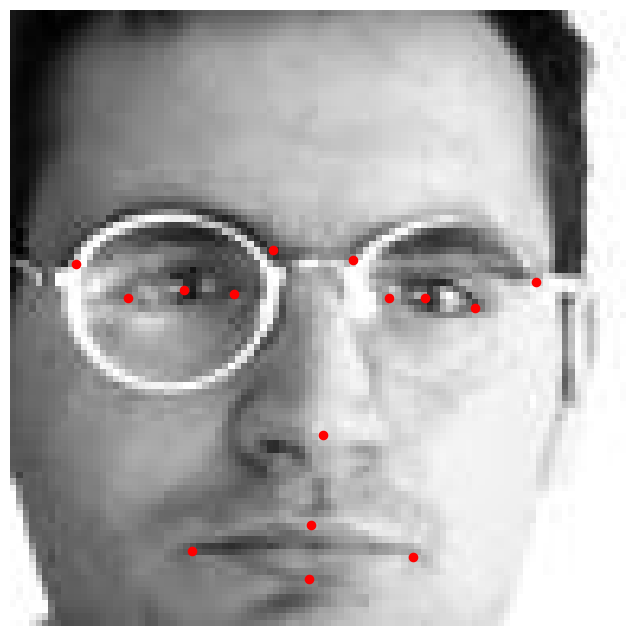

In [40]:
# STEP 4: VISUALIZE LANDMARKS

image_id = 1500   # Change to any image number

img = cv2.imread(f'/content/dataset/images/train_images/{image_id}.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)

for i in range(0,30,2):
    x = df.iloc[image_id, i]
    y = df.iloc[image_id, i+1]
    plt.scatter(x, y, c='red', s=35)

plt.axis('off')
plt.show()

In [31]:
# STEP 5: LOAD IMAGES

images = []
labels = []

for i in range(len(df)):

    img_path = f'/content/dataset/images/train_images/{i}.jpg'

    img = cv2.imread(img_path)

    if img is not None:

        img = img / 255.0

        images.append(img)
        labels.append(df.iloc[i].values)

X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(7049, 96, 96, 3)
(7049, 30)


In [32]:
# STEP 6: SPLIT DATASET

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(5639, 96, 96, 3)
(1410, 96, 96, 3)


In [33]:
# STEP 7: BUILD CNN MODEL

model = Sequential([

    Input(shape=(96,96,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512,activation='relu'),

    Dense(30)

])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,662,750 (25.42 MB)

 Trainable params: 6,662,750 (25.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 8: TRAIN MODEL

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 116s 646ms/step - loss: 121.6003 - mae: 6.3751 - val_loss: 12.0121 - val_mae: 2.4434
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 105s 593ms/step - loss: 10.2406 - mae: 2.1017 - val_loss: 8.5967 - val_mae: 1.8171
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 145s 608ms/step - loss: 8.3806 - mae: 1.7933 - val_loss: 17.1161 - val_mae: 3.3302
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 102s 574ms/step - loss: 8.0461 - mae: 1.7596 - val_loss: 7.5330 - val_mae: 1.6976
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 144s 590ms/step - loss: 7.3631 - mae: 1.6988 - val_loss: 9.0368 - val_mae: 2.0796
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 103s 584ms/step - loss: 7.9020 - mae: 1.8971 - val_loss: 6.1973 - val_mae: 1.5427
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 112s 633ms/step - loss: 6.6322 - mae: 1.6641 - val_loss: 7.0544 - val_mae: 1.8581
Epoch 8/10
138/177 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step - loss: 6.8704 - mae: 1.7326

In [ ]:
# STEP 9: PLOT LOSS GRAPH

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
# STEP 10: SAVE MODEL

model.save("landmark_detection_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


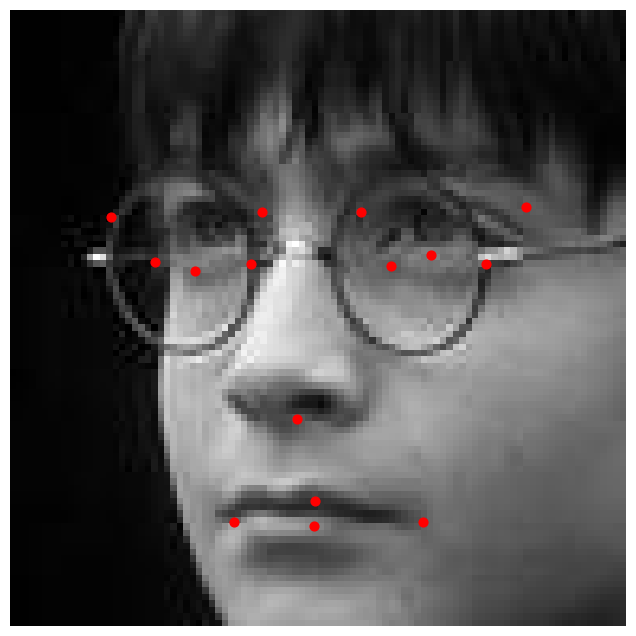

In [37]:
sample = X_val[1000]   # Try 100, 500, 1000, etc.

prediction = model.predict(
    np.expand_dims(sample, axis=0)
)

prediction = prediction.reshape(15,2)

plt.figure(figsize=(8,8))
plt.imshow(sample)

for x,y in prediction:
    plt.scatter(x,y,c='red',s=40)

plt.axis('off')
plt.show()